In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/UDEA-Esp-Analitica-y-Ciencia-de-Datos/EACD-04-MACHINE-LEARNING-1/master/init.py
import init; init.init(force_download=False)

replicating local resources


# 11b. SHAP Values — Interpretabilidad de Modelos de Machine Learning

**Especialización en Analítica y Ciencia de Datos**  
Facultad de Ingeniería · Universidad de Antioquia

---

## Contenido

1. [¿Por qué necesitamos interpretabilidad?](#1)
2. [Teoría de Juegos y Valores de Shapley](#2)
3. [De Shapley a SHAP](#3)
4. [Tipos de explicaciones SHAP](#4)
5. [SHAP en la práctica: TreeExplainer](#5)
6. [SHAP para modelos lineales: LinearExplainer](#6)
7. [Análisis global vs. local](#7)
8. [SHAP en un pipeline de selección de características](#8)
9. [**[TALLER]** Interpretando un clasificador de riesgo crediticio](#9)

---

## 1. ¿Por qué necesitamos interpretabilidad? <a id='1'></a>

Cuando entrenamos un modelo de ML, nos hacemos preguntas como:

- ¿Por qué el modelo clasificó este cliente como riesgo alto?
- ¿Qué variables son realmente importantes?
- ¿El modelo está usando señales correctas o está haciendo *spurious correlations*?

Los modelos complejos (Random Forest, GBT, redes neuronales) son inherentemente **cajas negras**: producen predicciones precisas pero ofrecen poca transparencia sobre cómo llegan a ellas.

Esto importa especialmente en contextos regulados (crédito, salud, justicia), donde las decisiones automatizadas deben ser explicables.

| Tipo de modelo       | Precisión | Interpretabilidad |
|----------------------|-----------|-------------------|
| Regresión Lineal     | Media     | Alta              |
| Árbol de Decisión    | Media     | Alta              |
| Random Forest / GBT  | Alta      | **Baja**          |
| Redes Neuronales     | Muy Alta  | **Muy baja**      |

**SHAP** nos da lo mejor de ambos mundos: usamos modelos potentes *y* podemos explicar cada predicción de forma rigurosa.

## 2. Teoría de Juegos y Valores de Shapley <a id='2'></a>

SHAP se fundamenta en los **valores de Shapley**, concepto introducido por Lloyd Shapley en 1953 en el contexto de la teoría de juegos cooperativos.

### La intuición

Imagina un equipo de vendedores que juntos generan una utilidad total. ¿Cuánto contribuyó *cada uno* al resultado final?

La solución de Shapley responde esto de forma **justa**: calcula la contribución marginal promedio de cada jugador, considerando **todas las posibles combinaciones** (coaliciones) en que podría participar.

### Fórmula

Para un jugador $i$ en un juego con $n$ jugadores y función de utilidad $v$:

$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! \cdot (n - |S| - 1)!}{n!} \left[ v(S \cup \{i\}) - v(S) \right]$$

Donde:
- $S$ es una coalición (subconjunto de jugadores) que **no** incluye a $i$
- $v(S)$ es la utilidad que genera la coalición $S$
- $v(S \cup \{i\})$ es la utilidad cuando $i$ se une a $S$
- El prefactor es el peso de cada coalición (proporcional a cuántas permutaciones la generan)

En palabras: el valor de Shapley de $i$ es la **contribución marginal promedio** de $i$ sobre todas las coaliciones posibles.

### Propiedades axiomáticas (¡importantes!)

| Propiedad       | Descripción |
|-----------------|-------------|
| **Eficiencia** | Las contribuciones suman exactamente la predicción total |
| **Simetría**   | Dos jugadores con igual contribución reciben igual valor |
| **Linealidad** | Se puede descomponer en juegos simples |
| **Dummy**      | Un jugador que no aporta nada recibe $\phi = 0$ |

## 3. De Shapley a SHAP <a id='3'></a>

**SHAP** (*SHapley Additive exPlanations*) fue propuesto por Lundberg & Lee (2017). Adapta los valores de Shapley al contexto de ML:

- **Jugadores** → variables (features) del modelo
- **Juego** → la predicción del modelo
- **Utilidad de una coalición** → predicción esperada cuando solo se conocen las features de esa coalición

Para una observación $x$, el modelo se explica como:

$$f(x) = \underbrace{\phi_0}_{\text{predicción base}} + \sum_{i=1}^{n} \underbrace{\phi_i(x)}_{\text{SHAP value de feature } i}$$

Donde:
- $\phi_0 = E[f(X)]$ es la predicción promedio del modelo (valor base)
- $\phi_i(x)$ es cuánto *sube o baja* la predicción respecto al promedio gracias a la feature $i$

### ¿Cómo se calcula en la práctica?

El cálculo exacto es exponencial en el número de features ($2^n$ coaliciones). SHAP ofrece **aproximaciones eficientes** según el tipo de modelo:

| Explainer         | Modelo objetivo                    | Complejidad |
|-------------------|------------------------------------|-------------|
| `TreeExplainer`   | Random Forest, GBT, XGBoost        | O(TLD²)     |
| `LinearExplainer` | Regresión lineal / logística        | O(n)        |
| `KernelExplainer` | Cualquier modelo (model-agnostic)   | O(2^n·k)    |
| `DeepExplainer`   | Redes neuronales (TensorFlow/PyTorch)| O(n·s)     |

## Setup e instalación

In [2]:
!pip install shap -q

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

import shap
shap.initjs()  # Habilita visualizaciones interactivas en Jupyter

import warnings
warnings.filterwarnings('ignore')

print('Versión SHAP:', shap.__version__)
print('Setup completado ✓')

Versión SHAP: 0.52.0
Setup completado ✓


## 4. Tipos de explicaciones SHAP <a id='4'></a>

SHAP ofrece dos niveles de análisis:

### 4.1 Explicación local (por observación)
Responde: *¿Por qué el modelo predijo esto para **este** paciente/cliente/caso específico?*

Usa el **Force Plot**: muestra las features que empujan la predicción hacia arriba (rojo) o hacia abajo (azul) respecto al valor base.

### 4.2 Explicación global (sobre el dataset)
Responde: *¿Qué features son más importantes para el modelo en general?*

Usa el **Summary Plot (Beeswarm)**: muestra todos los SHAP values para cada feature, con el valor real codificado en color.

```
Predicción base (E[f(x)])
        |
        ├─ feature_1: +0.32  (sube la predicción)
        ├─ feature_2: -0.18  (baja la predicción)
        ├─ feature_3: +0.07
        └─ ...              
        |
Predicción final f(x) = E[f(x)] + sum(phi_i)
```

## 5. SHAP en la práctica: TreeExplainer <a id='5'></a>

Vamos a trabajar con el dataset **Breast Cancer** (clasificación binaria: tumor maligno vs. benigno). Usaremos un `GradientBoostingClassifier` como modelo base.

In [6]:
# ── Cargar datos ──────────────────────────────────────────────────────────────
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = maligno, 1 = benigno

print('Shape:', X.shape)
print('Clases:', dict(zip(*np.unique(y, return_counts=True))))
X.head(3)

Shape: (569, 30)
Clases: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [7]:
# ── Entrenar modelo ───────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

gbt = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
gbt.fit(X_train, y_train)

y_pred_proba = gbt.predict_proba(X_test)[:, 1]
print(f'ROC-AUC en test: {roc_auc_score(y_test, y_pred_proba):.4f}')
print(classification_report(y_test, gbt.predict(X_test),
                             target_names=data.target_names))

ROC-AUC en test: 0.9888
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [8]:
# ── Calcular SHAP values con TreeExplainer ────────────────────────────────────
explainer = shap.TreeExplainer(gbt)
shap_values = explainer.shap_values(X_test)

# Para clasificación binaria, GBT retorna un array (no lista)
print('Tipo shap_values:', type(shap_values))
print('Shape shap_values:', shap_values.shape)
print('Valor base (E[f(x)]):', explainer.expected_value)

Tipo shap_values: <class 'numpy.ndarray'>
Shape shap_values: (114, 30)
Valor base (E[f(x)]): [2.54790218]


In [10]:
# ── Verificar propiedad de EFICIENCIA ─────────────────────────────────────────
# Para la observación 0: phi_0 + sum(phi_i) debe ser igual a f(x)
idx = 0
phi_0 = explainer.expected_value
phi_sum = shap_values[idx].sum()
f_x = gbt.predict_proba(X_test.iloc[[idx]])[:, 1][0]

# Nota: en GBT el explainer opera en espacio log-odds; aquí mostramos la suma
print(f'Valor base (phi_0):        {phi_0[0]:.4f}')
print(f'Suma de SHAP values:        {phi_sum:.4f}')
print(f'phi_0 + suma:               {(phi_0 + phi_sum)[0]:.4f}')
print(f'Predicción log-odds f(x):   {gbt.decision_function(X_test.iloc[[idx]])[0]:.4f}')
print()
print('✓ Propiedad de eficiencia verificada: phi_0 + Σ(phi_i) = f(x)')

Valor base (phi_0):        2.5479
Suma de SHAP values:        -12.6640
phi_0 + suma:               -10.1161
Predicción log-odds f(x):   -10.1161

✓ Propiedad de eficiencia verificada: phi_0 + Σ(phi_i) = f(x)


### 5.1 Importancia global — Summary Plot (Beeswarm)

El **Summary Plot** muestra:
- **Eje Y**: features ordenadas de mayor a menor impacto global
- **Eje X**: valor SHAP (positivo = aumenta la probabilidad de clase 1)
- **Color**: valor real de la feature (rojo = alto, azul = bajo)

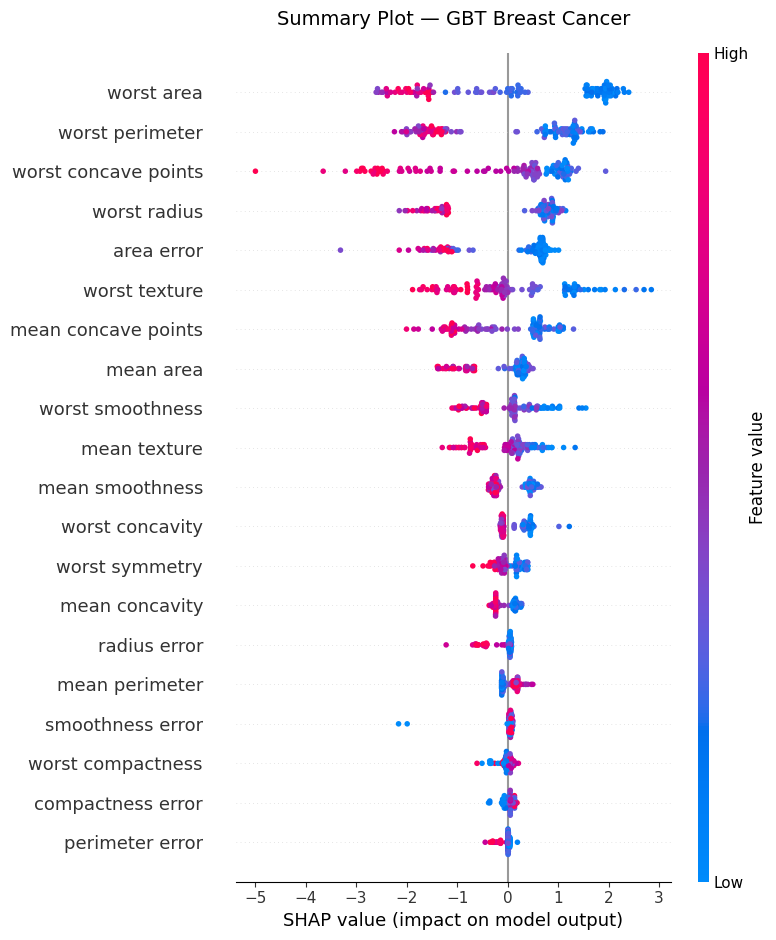

In [11]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Summary Plot — GBT Breast Cancer', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

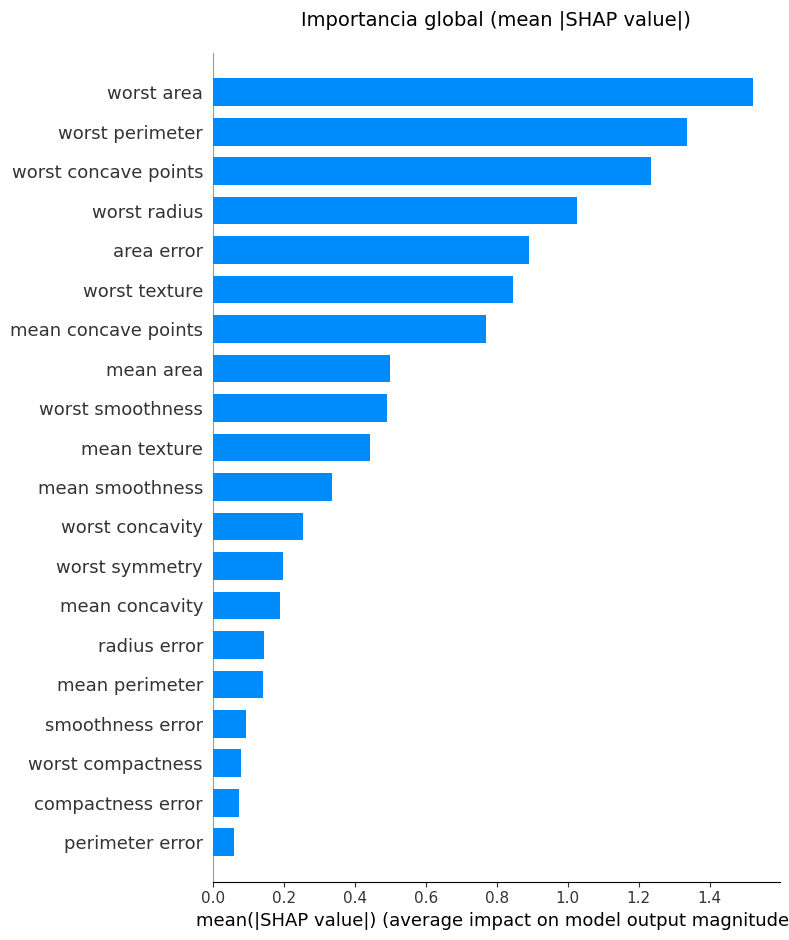

In [12]:
# ── Bar plot: importancia global promedio |SHAP| ───────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Importancia global (mean |SHAP value|)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### 5.2 Explicación local — Force Plot

El **Force Plot** explica una predicción individual:
- La barra roja indica features que **aumentan** la predicción respecto a la base
- La barra azul indica features que la **disminuyen**
- La suma de todos los efectos da la predicción final

Observación 0:
  Etiqueta real:        malignant
  Probabilidad pred.:   0.0000



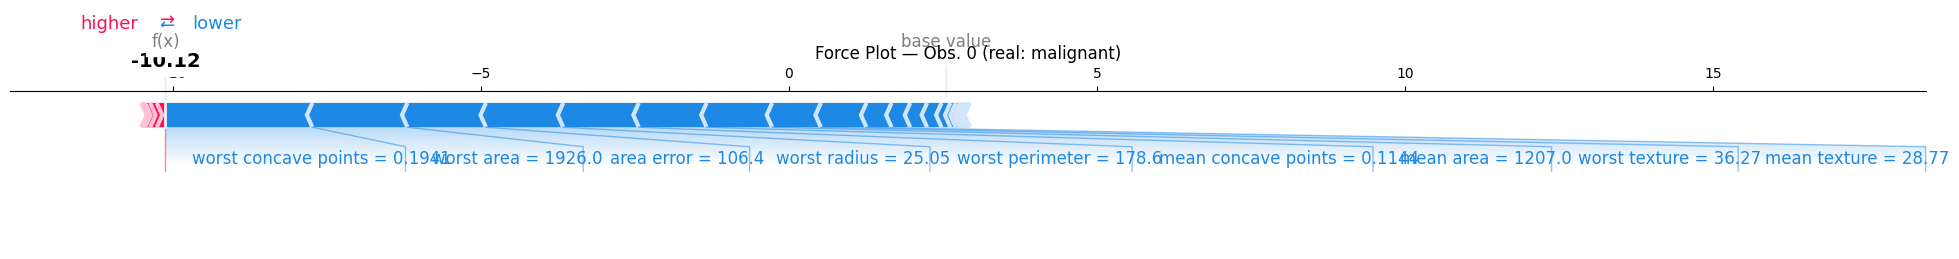

In [14]:
# ── Force plot para la observación 0 ──────────────────────────────────────────
idx = 0
print(f'Observación {idx}:')
print(f'  Etiqueta real:        {data.target_names[y_test[idx]]}')
print(f'  Probabilidad pred.:   {gbt.predict_proba(X_test.iloc[[idx]])[:, 1][0]:.4f}')
print()

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True,
    show=False
)
plt.title(f'Force Plot — Obs. {idx} (real: {data.target_names[y_test[idx]]})')
plt.tight_layout()
plt.show()

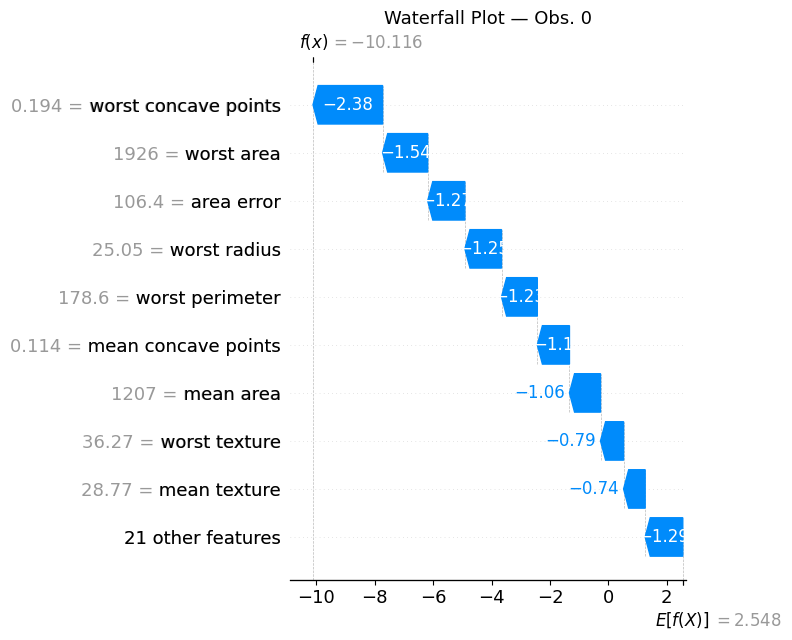

In [15]:
# ── Waterfall plot (alternativa moderna al force plot) ────────────────────────
# Muestra las features que más mueven la predicción, de forma acumulada
shap_explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx].values,
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_explanation, show=False)
plt.title(f'Waterfall Plot — Obs. {idx}', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Dependence Plot

El **Dependence Plot** muestra cómo varía el SHAP value de una feature en función de su valor real. Permite detectar:
- Relaciones no lineales
- Interacciones con otras variables (codificadas en el color)

Feature más importante: worst area


<Figure size 900x500 with 0 Axes>

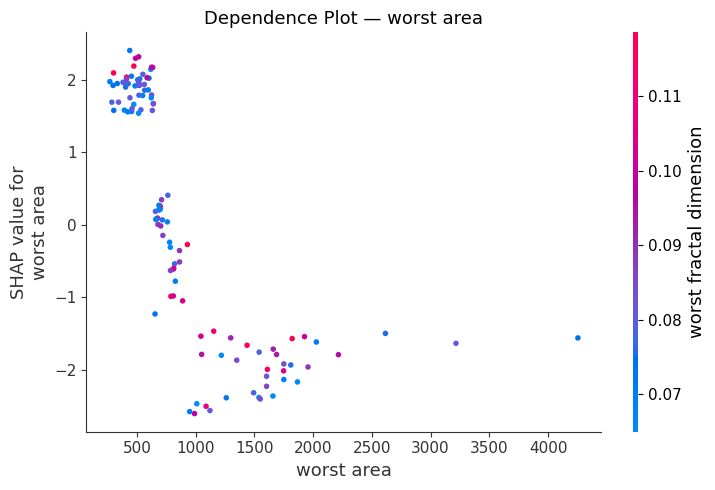

In [16]:
# ── Dependence plot para la feature más importante ────────────────────────────
top_feature = pd.DataFrame(
    np.abs(shap_values), columns=X_test.columns
).mean().idxmax()

print(f'Feature más importante: {top_feature}')

plt.figure(figsize=(9, 5))
shap.dependence_plot(
    top_feature,
    shap_values,
    X_test,
    interaction_index='auto',  # SHAP elige la interacción más fuerte
    show=False
)
plt.title(f'Dependence Plot — {top_feature}', fontsize=13)
plt.tight_layout()
plt.show()

## 6. SHAP para modelos lineales: LinearExplainer <a id='6'></a>

Para modelos lineales el cálculo es exacto y muy eficiente. Los SHAP values se relacionan directamente con los coeficientes:

$$\phi_i(x) = \beta_i \cdot (x_i - E[x_i])$$

Es decir: la contribución de una feature es proporcional a su coeficiente, ponderada por cuánto se *desvía del promedio* en esta observación.

In [17]:
# ── Pipeline: StandardScaler + LogisticRegression ─────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

print(f'ROC-AUC (LogReg): {roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:, 1]):.4f}')

# ── LinearExplainer ───────────────────────────────────────────────────────────
explainer_lr = shap.LinearExplainer(lr, X_train_sc, feature_perturbation='interventional')
shap_values_lr = explainer_lr.shap_values(X_test_sc)

# Para clasificación binaria, LinearExplainer retorna lista [clase0, clase1]
if isinstance(shap_values_lr, list):
    sv_lr = shap_values_lr[1]  # SHAP values para clase 1 (benigno)
else:
    sv_lr = shap_values_lr

print('Shape SHAP values LR:', sv_lr.shape)

ROC-AUC (LogReg): 0.9954
Shape SHAP values LR: (114, 30)


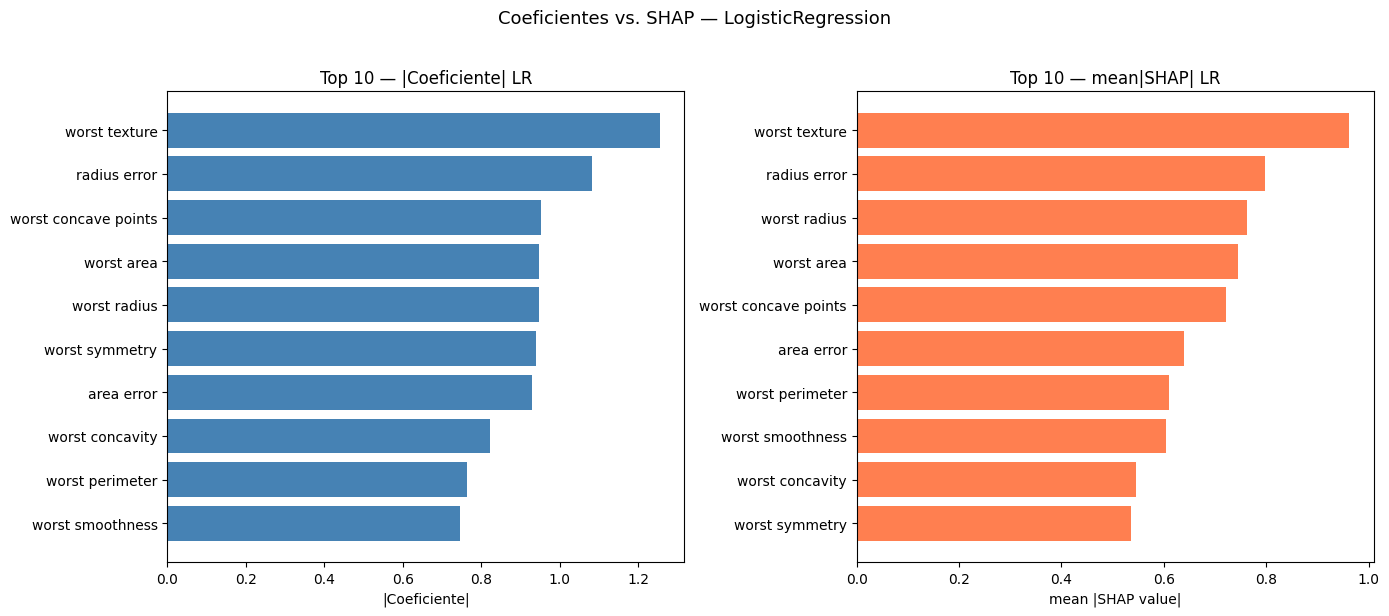

Nota: los coeficientes dan importancia global; SHAP también considera
la distribución de cada feature (magnitud * varianza).


In [18]:
# ── Comparar: coeficientes del modelo vs. importancia SHAP ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Coeficientes (magnitud)
coef_df = pd.Series(np.abs(lr.coef_[0]), index=X.columns).sort_values(ascending=False).head(10)
axes[0].barh(coef_df.index[::-1], coef_df.values[::-1], color='steelblue')
axes[0].set_title('Top 10 — |Coeficiente| LR', fontsize=12)
axes[0].set_xlabel('|Coeficiente|')

# SHAP importancia global
shap_imp = pd.Series(np.abs(sv_lr).mean(axis=0), index=X.columns).sort_values(ascending=False).head(10)
axes[1].barh(shap_imp.index[::-1], shap_imp.values[::-1], color='coral')
axes[1].set_title('Top 10 — mean|SHAP| LR', fontsize=12)
axes[1].set_xlabel('mean |SHAP value|')

plt.suptitle('Coeficientes vs. SHAP — LogisticRegression', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print('Nota: los coeficientes dan importancia global; SHAP también considera\n'
      'la distribución de cada feature (magnitud * varianza).')

## 7. Análisis global vs. local: juntando las piezas <a id='7'></a>

Una estrategia típica en producción es:

1. **Nivel global**: usar el Summary Plot / Bar Plot para comunicar al negocio qué variables importan
2. **Nivel local**: para cada predicción de riesgo alto, mostrar un Force Plot o Waterfall para justificar la decisión
3. **Nivel de feature**: usar Dependence Plots para detectar relaciones no lineales o umbrales

### 7.1 Detección de observaciones anómalas

Podemos usar los SHAP values para encontrar observaciones donde el modelo se comporta de forma atípica.

In [21]:
# ── SHAP values como DataFrame para análisis ──────────────────────────────────
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# Observación con mayor 'sorpresa' (mayor norma L2 de sus SHAP values)
shap_norm = np.linalg.norm(shap_values, axis=1)
idx_max = np.argmax(shap_norm)

print(f'Observación más extrema: índice {idx_max}')
print(f'  Real:      {data.target_names[y_test[idx_max]]}')
print(f'  Pred prob: {gbt.predict_proba(X_test.iloc[[idx_max]])[:, 1][0]:.4f}')
print()
print('Top 5 features con mayor impacto absoluto:')
print(shap_df.iloc[idx_max].abs().sort_values(ascending=False).head(5))

Observación más extrema: índice 102
  Real:      malignant
  Pred prob: 0.0002

Top 5 features con mayor impacto absoluto:
worst concave points    4.993764
worst perimeter         1.773142
mean concave points     1.491873
worst texture           1.140246
worst smoothness        1.099804
Name: 102, dtype: float64


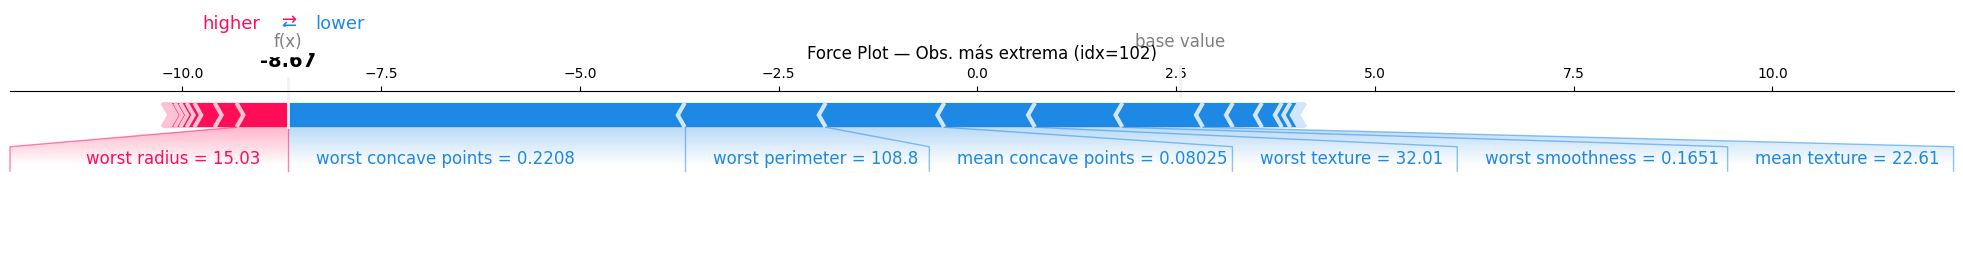

In [22]:
# ── Force plot de la observación más extrema ──────────────────────────────────
shap.force_plot(
    explainer.expected_value,
    shap_values[idx_max],
    X_test.iloc[idx_max],
    matplotlib=True,
    show=False
)
plt.title(f'Force Plot — Obs. más extrema (idx={idx_max})', fontsize=12)
plt.tight_layout()
plt.show()

## 8. SHAP en un pipeline de selección de características <a id='8'></a>

Los SHAP values pueden usarse para **selección de features**: eliminamos las features con menor importancia global (mean |SHAP|) y verificamos si el modelo mantiene su desempeño.

Esto es más robusto que la importancia basada en *impurity decrease* (la que viene por defecto en sklearn), porque:
- Considera la distribución real de los datos
- Detecta multicolinealidad mejor
- Es consistente: si una feature es más importante, su SHAP nunca decrece

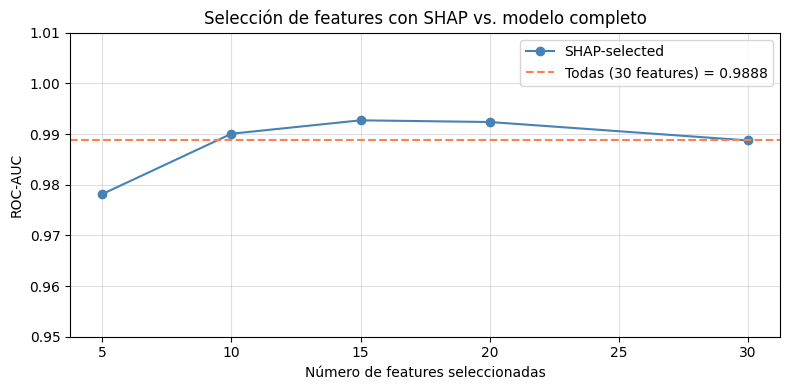

 n_features  ROC-AUC
          5 0.978175
         10 0.990079
         15 0.992725
         20 0.992394
         30 0.988757


In [23]:
# ── Selección de features basada en SHAP ──────────────────────────────────────
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

resultados = []
for k in [5, 10, 15, 20, 30]:
    top_features = shap_importance.head(k).index.tolist()
    gbt_k = GradientBoostingClassifier(n_estimators=150, max_depth=3, random_state=42)
    gbt_k.fit(X_train[top_features], y_train)
    auc_k = roc_auc_score(y_test, gbt_k.predict_proba(X_test[top_features])[:, 1])
    resultados.append({'n_features': k, 'ROC-AUC': auc_k})

# Baseline con todas las features
auc_all = roc_auc_score(y_test, gbt.predict_proba(X_test)[:, 1])

res_df = pd.DataFrame(resultados)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res_df['n_features'], res_df['ROC-AUC'], marker='o', color='steelblue', label='SHAP-selected')
ax.axhline(auc_all, color='coral', linestyle='--', label=f'Todas ({X_test.shape[1]} features) = {auc_all:.4f}')
ax.set_xlabel('Número de features seleccionadas')
ax.set_ylabel('ROC-AUC')
ax.set_title('Selección de features con SHAP vs. modelo completo')
ax.legend()
ax.set_ylim(0.95, 1.01)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(res_df.to_string(index=False))

---

## 9. [TALLER] Interpretando un clasificador de riesgo crediticio <a id='9'></a>

**Objetivo**: entrenar un modelo de riesgo crediticio sintético, calcular SHAP values y producir un reporte de interpretabilidad completo.

### Datos

Generaremos un dataset sintético de clientes con las siguientes features:

| Feature             | Descripción |
|---------------------|-------------|
| `ingreso_mensual`   | Ingreso mensual del cliente (COP) |
| `deuda_total`       | Total deuda vigente |
| `meses_empleo`      | Antigüedad laboral en meses |
| `num_productos`     | Número de productos financieros activos |
| `dias_mora_hist`    | Días promedio de mora histórica |
| `edad`              | Edad del cliente |
| `score_buro`        | Puntaje de buró de crédito |
| `porc_utilizacion`  | Porcentaje de utilización del cupo |

**Target**: `default` (1 = incumplió, 0 = cumplió)

---

In [24]:
# ── Generación del dataset sintético ─────────────────────────────────────────
np.random.seed(42)
n = 2000

ingreso_mensual  = np.random.lognormal(mean=14.5, sigma=0.6, size=n).clip(500_000, 20_000_000)
deuda_total      = np.random.lognormal(mean=15.0, sigma=0.8, size=n).clip(0, 50_000_000)
meses_empleo     = np.random.exponential(scale=36, size=n).clip(0, 360).astype(int)
num_productos    = np.random.randint(1, 8, size=n)
dias_mora_hist   = np.random.exponential(scale=15, size=n).clip(0, 180)
edad             = np.random.randint(20, 70, size=n)
score_buro       = (800 - dias_mora_hist * 2 + np.random.normal(0, 30, n)).clip(300, 850)
porc_utilizacion = np.random.beta(2, 3, size=n)

# Probabilidad de default (función logística de las features)
log_odds = (
    -3.0
    - 0.4 * (ingreso_mensual / 1e6)
    + 0.3 * (deuda_total / 1e6)
    - 0.02 * meses_empleo
    + 0.04 * dias_mora_hist
    - 0.005 * score_buro
    + 1.5 * porc_utilizacion
    + np.random.normal(0, 0.5, n)
)
prob_default = 1 / (1 + np.exp(-log_odds))
default = (np.random.uniform(size=n) < prob_default).astype(int)

credito_df = pd.DataFrame({
    'ingreso_mensual' : ingreso_mensual,
    'deuda_total'     : deuda_total,
    'meses_empleo'    : meses_empleo,
    'num_productos'   : num_productos,
    'dias_mora_hist'  : dias_mora_hist,
    'edad'            : edad,
    'score_buro'      : score_buro,
    'porc_utilizacion': porc_utilizacion,
    'default'         : default
})

print(f'Dataset creado: {credito_df.shape}')
print(f'Tasa de default: {credito_df["default"].mean():.2%}')
credito_df.head()

Dataset creado: (2000, 9)
Tasa de default: 1.50%


,ingreso_mensual,deuda_total,meses_empleo,num_productos,dias_mora_hist,edad,score_buro,porc_utilizacion,default
0,2.671174e+06,1.904742e+06,23,4,21.454277,57,710.005223,0.375375,0
1,1.824910e+06,2.912100e+06,3,6,0.239473,66,783.188635,0.569224,0
2,2.924439e+06,1.734213e+06,129,7,12.240239,27,777.782015,0.741497,0
3,4.944656e+06,2.555174e+06,26,5,7.157512,26,762.687214,0.281358,0
4,1.722880e+06,7.186346e+05,34,2,10.595006,21,788.615585,0.575018,0


---
### Ejercicios del taller

**Ejercicio 1** (20 pts)  
Entrena un `RandomForestClassifier` con los datos de crédito. Reporta ROC-AUC en conjunto de test. Usa `random_state=42`.

**Ejercicio 2** (20 pts)  
Calcula los SHAP values usando `TreeExplainer`. Genera el Summary Plot y el Bar Plot. ¿Cuáles son las 3 features más importantes? ¿Tiene sentido de negocio?

**Ejercicio 3** (20 pts)  
Selecciona el cliente con mayor probabilidad predicha de default. Genera su Force Plot y Waterfall Plot. Describe en términos de negocio *por qué* el modelo lo clasifica como de riesgo alto.

**Ejercicio 4** (20 pts)  
Genera el Dependence Plot de `score_buro` y `porc_utilizacion`. Describe la relación que muestra cada gráfico.

**Ejercicio 5** (20 pts — opcional avanzado)**  
Compara la importancia SHAP del Random Forest con la importancia por `feature_importances_` nativa de sklearn. ¿Hay diferencias? ¿A cuál le darías más credibilidad y por qué?

---

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# EJERCICIO 1: Entrenamiento del modelo
# ─────────────────────────────────────────────────────────────────────────────

X_cred = credito_df.drop(columns='default')
y_cred = credito_df['default']

# Tu código aquí ↓


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# EJERCICIO 2: SHAP values y Summary Plot
# ─────────────────────────────────────────────────────────────────────────────

# Tu código aquí ↓


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# EJERCICIO 3: Explicación local del cliente con mayor riesgo
# ─────────────────────────────────────────────────────────────────────────────

# Tu código aquí ↓


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# EJERCICIO 4: Dependence Plots
# ─────────────────────────────────────────────────────────────────────────────

# Tu código aquí ↓


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# EJERCICIO 5 (opcional): SHAP vs. feature_importances_
# ─────────────────────────────────────────────────────────────────────────────

# Tu código aquí ↓


---

## Resumen

| Concepto | Descripción |
|----------|-------------|
| **SHAP value** | Contribución marginal promedio de una feature a la predicción, según teoría de juegos de Shapley |
| **Propiedad de eficiencia** | $\phi_0 + \sum \phi_i = f(x)$ — la predicción se descompone exactamente |
| **TreeExplainer** | Algoritmo exacto y eficiente para árboles (RF, GBT, XGBoost) |
| **LinearExplainer** | SHAP exacto para modelos lineales; proporcional a $\beta_i \cdot (x_i - \bar{x}_i)$ |
| **Summary Plot** | Vista global: qué features importan y en qué dirección |
| **Force / Waterfall** | Vista local: por qué se predijo X para este caso específico |
| **Dependence Plot** | Relación entre el valor de una feature y su SHAP value |

### Lecturas recomendadas

- Lundberg, S. & Lee, S. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 2017. [arXiv](https://arxiv.org/abs/1705.07874)
- Molnar, C. *Interpretable Machine Learning* (libro open-access). [https://christophm.github.io/interpretable-ml-book/](https://christophm.github.io/interpretable-ml-book/)
- Documentación oficial SHAP: [https://shap.readthedocs.io](https://shap.readthedocs.io)

---
*Especialización en Analítica y Ciencia de Datos · Facultad de Ingeniería · Universidad de Antioquia*